In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd

In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [4]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_lstm_3level
📌 Features: 71
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [5]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/trading_model_gru_3level
📌 Features: 71
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [6]:
ASSET

'GC'

In [7]:
def load_bt_csv(ticker):
    data = pd.read_parquet(f"{BT_DIR}/{ticker}1min.parquet")
    data["openint"] = 0
    data["datetime"] = pd.to_datetime(data["time"], utc=True)
    # Cargar specs
    specs = load_specs()
    ticker = ticker.upper()
    if ticker not in specs:
        raise KeyError(f"No se encuentra spec para '{ticker}' en los JSON de info.")
    data = data.sort_values('datetime').drop_duplicates(subset='datetime').reset_index(drop=True)
    return data, specs[ticker]
    # return data

In [8]:
def prepare_bt(symbol, minutes, return_horizon_min, json_config_path="features_config.json"):
    df, spec = load_bt_csv(symbol)
    df = add_trading_date_by_gap(df)
    df_resampled = resample_ohlcv(df, period=f"{minutes}min")
    df_cumulative = daily_ohlcv_cummulative(df_resampled)
    config = load_feature_config()

    config["global"]["sampling_minutes"] = minutes
    config["global"]["return_horizon_min"] = return_horizon_min
    config["global"]["tick_size"] = spec["tick_size"]
    
    df_final = generate_features(df_cumulative, config)
    df_final["ticker"] = symbol
    return df_final, spec

In [9]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [10]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-26 00:00:00+00:00,4572.9,4593.9,4572.9,4593.6,38.0,0.0,240min,2025-12-25,4572.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
1,2025-12-26 04:00:00+00:00,4600.0,4625.7,4590.0,4606.6,110.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
2,2025-12-26 08:00:00+00:00,4599.6,4612.3,4599.6,4602.8,62.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
3,2025-12-26 12:00:00+00:00,4605.8,4619.5,4598.0,4599.8,82.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
4,2025-12-26 16:00:00+00:00,4599.8,4645.9,4599.8,4645.9,238.0,0.0,240min,2025-12-26,4600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764,2026-06-19 04:00:00+00:00,4183.3,4188.9,4171.1,4171.2,19.0,0.0,240min,2026-06-19,4183.3,...,0.236,-1.190416,-1.954416,4.0,8.0,16.475,13.162500,1.0,6.000,GC
765,2026-06-19 08:00:00+00:00,4171.2,4171.2,4171.2,4171.2,0.0,0.0,240min,2026-06-19,4183.3,...,0.236,-1.190416,-1.954416,4.0,8.0,16.475,13.162500,1.0,7.000,GC
766,2026-06-19 12:00:00+00:00,4171.2,4171.2,4171.2,4171.2,0.0,0.0,240min,2026-06-19,4183.3,...,0.236,-0.235514,-0.999514,4.0,7.0,16.475,29.414286,8.0,1.000,GC
767,2026-06-19 16:00:00+00:00,4171.2,4171.2,4141.1,4146.8,46.0,0.0,240min,2026-06-19,4183.3,...,0.236,-0.354018,-1.118018,4.0,7.0,16.475,29.414286,8.0,1.125,GC


In [11]:
start = "2026-03-27"
end   = "2026-06-01"

mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]


In [12]:
df_bt["datetime"].dt.hour

0       0
1       4
2       8
3      12
4      16
       ..
764     4
765     8
766    12
767    16
768    20
Name: datetime, Length: 769, dtype: int32

<Axes: ylabel='Frequency'>

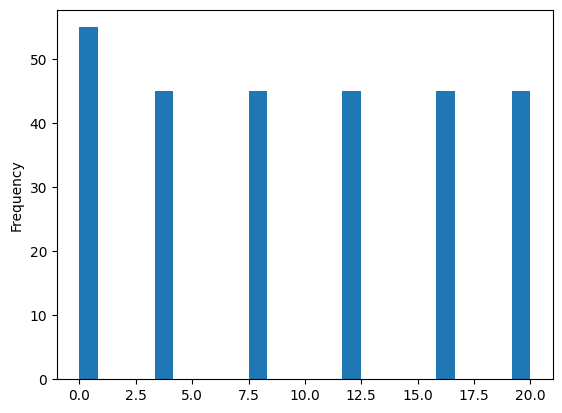

In [13]:
df_filtered["hour"] = df_filtered["datetime"].dt.hour
df_filtered["hour"].plot.hist(bins=24)


In [14]:
df_filtered[features]

,williams_r,is_ny,adx,return_lag_20,volume_cum,avg_volume,volume_delta,dist_low_cum_ticks,pct_above_ma_20,atr_norm,...,rolling_kurt_10,ad_z,dist_to_last_swing_low,ad_norm,bars_since_swing_low,obv_rel,rsi,roc_5,obv_roc_5,cmo
398,-79.810726,0,40.435925,-0.002675,62855.0,7118.80,-4994.0,512.0,-0.013803,0.017210,...,-1.151004,-1.850784,-0.019271,-218.392879,5.0,-0.513900,40.803163,-0.024779,0.105425,-2.455637
399,-66.758675,0,39.776274,0.007729,13901.0,7580.90,5622.0,637.0,-0.006785,0.016970,...,-1.154942,-0.513555,-0.011714,-61.452953,6.0,-0.390890,44.062922,-0.003815,-0.209112,5.459572
400,-62.618297,0,38.558095,0.009474,31695.0,8417.90,3893.0,742.0,-0.004449,0.015978,...,-1.275934,-1.032491,0.021183,-203.747760,0.0,-0.246332,45.095775,0.005211,-0.514777,-23.856949
401,-71.806723,0,37.757090,-0.021809,51465.0,9174.55,1976.0,465.0,-0.011380,0.015313,...,-1.269138,-1.680844,0.015087,-337.887045,1.0,-0.333760,42.848041,-0.004321,-0.101668,-33.881360
402,-26.890756,1,35.140060,0.017361,111099.0,11973.15,39864.0,1534.0,0.011250,0.017219,...,0.466930,1.949130,0.038205,128.949248,2.0,-0.006715,52.655591,0.036481,-0.980257,-3.345303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,-1.417129,0,24.099491,-0.002689,345.0,6581.85,-149.0,309.0,0.011020,0.008238,...,3.625681,-0.317991,0.035371,8257.482377,4.0,-3.582048,56.954485,0.031797,-0.005794,1.103878
674,-0.913764,0,23.213698,-0.004034,456.0,5968.55,13.0,444.0,0.014104,0.007965,...,3.635930,-0.216564,0.038241,5422.398736,5.0,-3.949192,59.089626,0.013334,-0.002072,12.011662
675,-10.643890,1,23.473043,-0.000947,772.0,5378.00,205.0,749.0,0.020592,0.009166,...,3.452215,-0.038999,0.044663,1975.814530,6.0,-4.379909,63.495171,0.016039,-0.001395,24.218750
676,-21.112571,1,23.713864,-0.006852,792.0,4235.45,-296.0,510.0,0.014842,0.008687,...,4.693697,0.022315,0.039638,6914.465900,7.0,-5.561664,58.205675,0.011532,-0.001594,36.063570


In [15]:
import numpy as np
import pandas as pd

def create_test_dataset(df, features, lookback=30):
    """
    Crea el dataset para LSTM usando NumPy strides (ultra rápido)
    y devuelve también los datetimes objetivo.
    
    Returns:
        X: np.ndarray de shape (num_samples, lookback, num_features)
        target_dt: pd.Series con los datetimes a predecir
    """
    # 1. Convertimos features a NumPy array
    feature_array = df[features].values
    
    # 2. Calculamos dimensiones
    num_samples = len(df) - lookback
    num_features = len(features)
    
    # 3. Crear ventanas con strides
    shape = (num_samples, lookback, num_features)
    strides = (feature_array.strides[0], feature_array.strides[0], feature_array.strides[1])
    
    X = np.lib.stride_tricks.as_strided(feature_array, shape=shape, strides=strides)
    
    # 4. Datetimes objetivo (los timestamps que vas a predecir)
    target_dt = df["datetime"].iloc[lookback:].reset_index(drop=True)
    
    return X, target_dt


In [16]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)

In [17]:
test_dt

0     2026-04-02 20:00:00+00:00
1     2026-04-03 00:00:00+00:00
2     2026-04-06 00:00:00+00:00
3     2026-04-06 04:00:00+00:00
4     2026-04-06 08:00:00+00:00
                 ...           
245   2026-05-29 08:00:00+00:00
246   2026-05-29 12:00:00+00:00
247   2026-05-29 16:00:00+00:00
248   2026-05-29 20:00:00+00:00
249   2026-05-30 00:00:00+00:00
Name: datetime, Length: 250, dtype: datetime64[us, UTC]

In [18]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)

In [19]:
test

array([[[-7.98107256e+01,  0.00000000e+00,  4.04359252e+01, ...,
         -2.47788390e-02,  1.05425373e-01, -2.45563721e+00],
        [-6.67586751e+01,  0.00000000e+00,  3.97762738e+01, ...,
         -3.81543130e-03, -2.09111775e-01,  5.45957153e+00],
        [-6.26182965e+01,  0.00000000e+00,  3.85580947e+01, ...,
          5.21114106e-03, -5.14777115e-01, -2.38569488e+01],
        ...,
        [-4.99208610e+01,  0.00000000e+00,  2.83804321e+01, ...,
         -2.34299820e-02, -3.38679277e-01,  2.60268318e+01],
        [-7.47940075e+01,  0.00000000e+00,  2.68986485e+01, ...,
         -3.90910602e-02, -6.12247525e-01,  8.50051706e+00],
        [-5.18352060e+01,  1.00000000e+00,  2.52721767e+01, ...,
         -2.17459357e-02, -2.53337184e-01,  1.73393124e+01]],

       [[-6.67586751e+01,  0.00000000e+00,  3.97762738e+01, ...,
         -3.81543130e-03, -2.09111775e-01,  5.45957153e+00],
        [-6.26182965e+01,  0.00000000e+00,  3.85580947e+01, ...,
          5.21114106e-03, -5.14777115e

In [20]:
test_flat = test.reshape(-1, test.shape[-1])


In [21]:
test_flat

array([[-7.98107256e+01,  0.00000000e+00,  4.04359252e+01, ...,
        -2.47788390e-02,  1.05425373e-01, -2.45563721e+00],
       [-6.67586751e+01,  0.00000000e+00,  3.97762738e+01, ...,
        -3.81543130e-03, -2.09111775e-01,  5.45957153e+00],
       [-6.26182965e+01,  0.00000000e+00,  3.85580947e+01, ...,
         5.21114106e-03, -5.14777115e-01, -2.38569488e+01],
       ...,
       [-9.13763564e-01,  0.00000000e+00,  2.32136979e+01, ...,
         1.33339289e-02, -2.07240505e-03,  1.20116618e+01],
       [-1.06438896e+01,  1.00000000e+00,  2.34730431e+01, ...,
         1.60386173e-02, -1.39477405e-03,  2.42187500e+01],
       [-2.11125712e+01,  1.00000000e+00,  2.37138635e+01, ...,
         1.15321252e-02, -1.59364238e-03,  3.60635697e+01]],
      shape=(7500, 71))

In [22]:
test_scaled =sc_features.transform(test_flat).reshape(test.shape)

In [23]:
import torch

def predict_in_batches(model, X_scaled, batch_size=512, device="cuda"):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_scaled), batch_size):
            batch = X_scaled[i:i+batch_size]
            batch_t = torch.tensor(batch, dtype=torch.float32).to(device)
            logits = model(batch_t)
            preds.append(logits.cpu())

    return torch.cat(preds, dim=0)


In [24]:
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()


In [25]:
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)

In [26]:
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()


In [27]:
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)

In [28]:
df_probs[["prob_short", "prob_long"]] = df_probs_l2


In [29]:
thresholds

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [30]:
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)


In [31]:
df_probs["pred_l3"] = preds_l3

In [32]:
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)

In [33]:
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)

In [34]:
df_probs["datetime"] = test_dt.values

In [35]:
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)


In [36]:
df_final_triple_real = target_triple_barrier_interday(df_filtered, spec_bt, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [37]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker,target_tb_2d,logreturn_tb_2d,target_class,target_regression
398,2026-03-27 00:00:00+00:00,4393.3,4449.0,4380.4,4431.6,8279.0,0.0,240min,2026-03-26,4528.2,...,10.0,32.922222,11.700000,4.0,2.250000,GC,1.0,NaN,1.0,-0.033069
399,2026-03-27 04:00:00+00:00,4431.2,4473.5,4401.0,4464.7,13901.0,0.0,240min,2026-03-27,4431.2,...,10.0,32.922222,11.700000,4.0,2.500000,GC,1.0,NaN,1.0,-0.029854
400,2026-03-27 08:00:00+00:00,4465.0,4502.6,4458.8,4475.2,17794.0,0.0,240min,2026-03-27,4431.2,...,7.0,32.922222,36.228571,11.0,1.000000,GC,1.0,NaN,1.0,-0.021422
401,2026-03-27 12:00:00+00:00,4475.3,4478.2,4432.2,4447.5,19770.0,0.0,240min,2026-03-27,4431.2,...,7.0,32.922222,36.228571,11.0,1.090909,GC,1.0,NaN,1.0,-0.035886
402,2026-03-27 16:00:00+00:00,4447.6,4585.3,4439.8,4554.4,59634.0,0.0,240min,2026-03-27,4431.2,...,7.0,32.922222,36.228571,11.0,1.181818,GC,1.0,NaN,1.0,-0.007895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,2026-05-29 00:00:00+00:00,4495.4,4495.6,4487.9,4491.8,114.0,0.0,240min,2026-05-28,4444.3,...,4.0,5.625000,25.625000,2.0,2.000000,GC,2.0,0.006468,2.0,-0.006170
672,2026-05-29 04:00:00+00:00,4493.6,4517.7,4492.6,4499.2,247.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625000,2.0,2.500000,GC,2.0,0.006139,2.0,0.000756
673,2026-05-29 08:00:00+00:00,4504.6,4523.5,4504.6,4523.5,98.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625000,2.0,3.000000,GC,2.0,0.005800,2.0,0.009507
674,2026-05-29 12:00:00+00:00,4518.8,4538.6,4509.8,4537.0,111.0,0.0,240min,2026-05-29,4493.6,...,4.0,5.625000,25.625000,2.0,3.500000,GC,2.0,0.005609,2.0,0.024860


In [38]:
df_final_triple_real["target_class"]

398    1.0
399    1.0
400    1.0
401    1.0
402    1.0
      ... 
671    2.0
672    2.0
673    2.0
674    2.0
675    1.0
Name: target_class, Length: 278, dtype: float64

In [39]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00,1
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00,1
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00,1
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00,1
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00,1
...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00,1
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00,1
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00,1
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00,1


In [40]:
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [41]:
df_merged = df_probs.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [42]:
df_merged

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,1.0
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,1.0
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,1.0
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,1.0
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,1.0
...,...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,2.0
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,2.0
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,1.0
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [43]:
df_merged.loc[df_merged.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
13,0.195310,0.804690,0.494292,0.505708,0.364485,1,1,2026-04-07 20:00:00+00:00,2,2.0
14,0.149485,0.850515,0.302341,0.697659,0.580965,1,1,2026-04-08 00:00:00+00:00,2,1.0
15,0.156969,0.843031,0.247386,0.752614,0.709339,1,1,2026-04-08 04:00:00+00:00,2,1.0
16,0.231300,0.768700,0.256198,0.743802,0.843261,1,1,2026-04-08 08:00:00+00:00,2,1.0
24,0.287583,0.712417,0.733843,0.266157,0.578748,1,0,2026-04-09 16:00:00+00:00,0,1.0
56,0.293406,0.706594,0.661803,0.338197,0.265666,1,0,2026-04-16 20:00:00+00:00,0,0.0
57,0.253498,0.746502,0.592002,0.407998,0.336024,1,0,2026-04-17 00:00:00+00:00,0,1.0
58,0.265614,0.734386,0.566279,0.433721,0.360220,1,0,2026-04-17 04:00:00+00:00,0,1.0
59,0.290343,0.709657,0.468118,0.531882,0.339043,1,1,2026-04-17 08:00:00+00:00,2,2.0
165,0.296599,0.703401,0.365327,0.634673,0.327598,1,1,2026-05-12 08:00:00+00:00,2,0.0


In [44]:
df_merged.loc[df_merged.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
11,0.363566,0.636434,0.870035,0.129965,0.003770,0,0,2026-04-07 12:00:00+00:00,1,2.0
12,0.312765,0.687235,0.839244,0.160756,-0.001498,0,0,2026-04-07 16:00:00+00:00,1,2.0
13,0.195310,0.804690,0.494292,0.505708,0.364485,1,1,2026-04-07 20:00:00+00:00,2,2.0
31,0.622170,0.377830,0.255905,0.744095,-0.326970,0,1,2026-04-10 20:00:00+00:00,1,0.0
32,0.554100,0.445900,0.331826,0.668174,-0.160813,0,1,2026-04-11 00:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
244,0.738652,0.261348,0.088117,0.911883,0.536056,0,1,2026-05-29 04:00:00+00:00,1,2.0
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,2.0
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,2.0
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [45]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])


In [46]:
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)

In [47]:
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()


In [48]:
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)

In [49]:
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()


In [50]:
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)

In [51]:
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g


In [52]:
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)


In [53]:
df_probs_g["pred_l3"] = preds_l3_g

In [54]:
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)

In [55]:
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)

In [56]:
df_probs_g["datetime"] = test_dt_g.values


In [57]:
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)


In [58]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.511113,0.488887,0.398143,0.601857,0.512302,0,1,2026-04-02 20:00:00,1
1,0.503138,0.496862,0.373288,0.626712,0.572988,0,1,2026-04-03 00:00:00,1
2,0.552210,0.447790,0.326690,0.673310,0.596102,0,1,2026-04-06 00:00:00,1
3,0.552374,0.447626,0.383737,0.616263,0.555722,0,1,2026-04-06 04:00:00,1
4,0.545767,0.454233,0.375766,0.624234,0.222781,0,1,2026-04-06 08:00:00,1
...,...,...,...,...,...,...,...,...,...
245,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00,1
246,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00,1
247,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00,1
248,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00,1


In [59]:
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [60]:
df_merged_g = df_probs_g.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [61]:
df_merged_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.511113,0.488887,0.398143,0.601857,0.512302,0,1,2026-04-02 20:00:00+00:00,1,1.0
1,0.503138,0.496862,0.373288,0.626712,0.572988,0,1,2026-04-03 00:00:00+00:00,1,1.0
2,0.552210,0.447790,0.326690,0.673310,0.596102,0,1,2026-04-06 00:00:00+00:00,1,1.0
3,0.552374,0.447626,0.383737,0.616263,0.555722,0,1,2026-04-06 04:00:00+00:00,1,1.0
4,0.545767,0.454233,0.375766,0.624234,0.222781,0,1,2026-04-06 08:00:00+00:00,1,1.0
...,...,...,...,...,...,...,...,...,...,...
245,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1,2.0
246,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1,2.0
247,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00+00:00,1,1.0
248,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [62]:
df_merged_g.loc[df_merged_g.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
8,0.330309,0.669691,0.505505,0.494495,0.181928,1,0,2026-04-07 00:00:00+00:00,0,1.0
9,0.320496,0.679504,0.439543,0.560457,0.035632,1,1,2026-04-07 04:00:00+00:00,2,1.0
10,0.341559,0.658441,0.624447,0.375553,-0.037056,1,0,2026-04-07 08:00:00+00:00,0,1.0
26,0.283150,0.716850,0.652699,0.347301,0.404883,1,0,2026-04-10 00:00:00+00:00,0,1.0
27,0.207776,0.792224,0.559276,0.440724,0.327220,1,0,2026-04-10 04:00:00+00:00,0,1.0
...,...,...,...,...,...,...,...,...,...,...
235,0.199595,0.800405,0.945653,0.054347,-0.901143,1,0,2026-05-27 16:00:00+00:00,0,1.0
236,0.206672,0.793328,0.956390,0.043610,-1.102446,1,0,2026-05-27 20:00:00+00:00,0,0.0
237,0.238866,0.761134,0.944609,0.055391,-1.111772,1,0,2026-05-28 00:00:00+00:00,0,0.0
238,0.267074,0.732926,0.926250,0.073750,-1.097828,1,0,2026-05-28 04:00:00+00:00,0,1.0


In [63]:
df_merged_g.loc[df_merged_g.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
11,0.422298,0.577702,0.793422,0.206578,-0.089122,0,0,2026-04-07 12:00:00+00:00,1,2.0
12,0.513160,0.486840,0.892021,0.107979,-0.117414,0,0,2026-04-07 16:00:00+00:00,1,2.0
13,0.533819,0.466181,0.614476,0.385524,0.038185,0,0,2026-04-07 20:00:00+00:00,1,2.0
31,0.213802,0.786198,0.386569,0.613431,-0.089719,1,1,2026-04-10 20:00:00+00:00,2,0.0
32,0.195878,0.804122,0.327868,0.672132,-0.085282,1,1,2026-04-11 00:00:00+00:00,2,0.0
...,...,...,...,...,...,...,...,...,...,...
244,0.753048,0.246952,0.111871,0.888129,0.427508,0,1,2026-05-29 04:00:00+00:00,1,2.0
245,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1,2.0
246,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1,2.0
248,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1,NaN


In [64]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1


In [65]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.511113,0.488887,0.398143,0.601857,0.512302,0,1,2026-04-02 20:00:00+00:00,1
1,0.503138,0.496862,0.373288,0.626712,0.572988,0,1,2026-04-03 00:00:00+00:00,1
2,0.552210,0.447790,0.326690,0.673310,0.596102,0,1,2026-04-06 00:00:00+00:00,1
3,0.552374,0.447626,0.383737,0.616263,0.555722,0,1,2026-04-06 04:00:00+00:00,1
4,0.545767,0.454233,0.375766,0.624234,0.222781,0,1,2026-04-06 08:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
245,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,2026-05-29 08:00:00+00:00,1
246,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,2026-05-29 12:00:00+00:00,1
247,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,2026-05-29 16:00:00+00:00,1
248,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,2026-05-29 20:00:00+00:00,1


In [66]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)


In [67]:
df_merged_total.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,0.511113,0.488887,0.398143,0.601857,0.512302,0,1,1
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,0.503138,0.496862,0.373288,0.626712,0.572988,0,1,1
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,0.552210,0.447790,0.326690,0.673310,0.596102,0,1,1
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,0.552374,0.447626,0.383737,0.616263,0.555722,0,1,1
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,0.545767,0.454233,0.375766,0.624234,0.222781,0,1,1


In [68]:
thresholds

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [69]:
thresholds_g

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [70]:
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [71]:
threshold_total

{'threshold_move': 0.65, 'threshold_dir': 0.5}

In [72]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [73]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

In [74]:
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [75]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [76]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,0.511113,0.488887,0.398143,0.601857,0.512302,0,1,1,0.496356,0.488782
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,0.503138,0.496862,0.373288,0.626712,0.572988,0,1,1,0.461941,0.485729
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,0.552210,0.447790,0.326690,0.673310,0.596102,0,1,1,0.557721,0.447544
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,0.552374,0.447626,0.383737,0.616263,0.555722,0,1,1,0.424686,0.446992
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,0.545767,0.454233,0.375766,0.624234,0.222781,0,1,1,0.021702,0.477673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,0.607346,0.392654,0.210890,0.789110,0.729171,0,1,1,1.634875,0.343551
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,0.511124,0.488876,0.152425,0.847575,1.190659,0,1,1,2.516529,0.433815
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,0.476289,0.523711,0.115426,0.884574,1.534445,0,1,1,3.140042,0.492544
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1,0.469930,0.530070,0.093405,0.906595,1.826458,0,1,1,3.693512,0.514681


In [77]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)


In [78]:
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])


In [79]:
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]


In [80]:
num_lstm_contra = cond_lstm.sum()


In [81]:
num_lstm_contra

np.int64(4)

In [82]:
cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]


In [83]:
num_gru_contra = cond_gru.sum()


In [84]:
num_gru_contra

np.int64(7)

In [85]:
df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [86]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,0.511113,...,0.601857,0.512302,0,1,1,0.496356,0.488782,0,NaN,NaN
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,0.503138,...,0.626712,0.572988,0,1,1,0.461941,0.485729,0,NaN,NaN
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,0.552210,...,0.673310,0.596102,0,1,1,0.557721,0.447544,0,NaN,NaN
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,0.552374,...,0.616263,0.555722,0,1,1,0.424686,0.446992,0,NaN,NaN
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,0.545767,...,0.624234,0.222781,0,1,1,0.021702,0.477673,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,0.607346,...,0.789110,0.729171,0,1,1,1.634875,0.343551,0,NaN,NaN
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,0.511124,...,0.847575,1.190659,0,1,1,2.516529,0.433815,0,NaN,NaN
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,0.476289,...,0.884574,1.534445,0,1,1,3.140042,0.492544,0,NaN,NaN
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1,0.469930,...,0.906595,1.826458,0,1,1,3.693512,0.514681,0,NaN,NaN


In [87]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [88]:
ratio_disagree

np.float64(0.1875)

In [89]:
ratio_l2_disagree

np.float64(0.109375)

In [90]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [91]:
summary

,metric,count,total_moves_softvote,ratio
0,L3_sign_disagree,12,64,0.187500
1,L2_direction_disagree,7,64,0.109375


In [94]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)


In [95]:
df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)


In [96]:
df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)


In [97]:
df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)


In [98]:
df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])


In [99]:
df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)


In [ ]:
df_merged_total["pred_final"]


,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,0.511113,...,0.488782,0,NaN,NaN,0.597998,0.402002,1,0.496356,1.0,1.0
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,0.503138,...,0.485729,0,NaN,NaN,0.607201,0.392799,1,0.461941,1.0,1.0
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,0.552210,...,0.447544,0,NaN,NaN,0.663980,0.336020,1,0.557721,1.0,1.0
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,0.552374,...,0.446992,0,NaN,NaN,0.590006,0.409994,1,0.424686,1.0,1.0
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,0.545767,...,0.477673,0,NaN,NaN,0.632392,0.367608,1,0.021702,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.695982,0.304018,0.127368,0.872632,0.905704,0,1,2026-05-29 08:00:00+00:00,1,0.607346,...,0.343551,0,NaN,NaN,0.835381,0.164619,1,0.826968,1.0,1.0
246,0.615632,0.384368,0.120050,0.879950,1.325870,0,1,2026-05-29 12:00:00+00:00,1,0.511124,...,0.433815,0,NaN,NaN,0.864632,0.135368,1,1.261897,1.0,1.0
247,0.537242,0.462758,0.106940,0.893060,1.605597,0,1,2026-05-29 16:00:00+00:00,1,0.476289,...,0.492544,0,NaN,NaN,0.888913,0.111087,1,1.570827,1.0,1.0
248,0.500372,0.499628,0.079756,0.920244,1.867055,0,1,2026-05-29 20:00:00+00:00,1,0.469930,...,0.514681,0,NaN,NaN,0.913495,0.086505,1,1.846979,1.0,1.0


In [107]:
df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [117]:
df_merged_final = df_merged_total.merge(df_final_triple_real[["datetime","target_class","target_regression"]], left_on="datetime", right_on="datetime", how="left")

In [118]:
df_merged_final.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,0.514578,0.485421,0.525983,0.474017,-0.015946,0,0,2026-04-02 20:00:00+00:00,1,0.511113,...,NaN,0.597998,0.402002,1,0.496356,1.0,1.0,1,1.0,-0.003273
1,0.571718,0.428282,0.493469,0.506531,-0.111047,0,1,2026-04-03 00:00:00+00:00,1,0.503138,...,NaN,0.607201,0.392799,1,0.461941,1.0,1.0,1,1.0,-0.004434
2,0.556277,0.443723,0.480928,0.519072,-0.038381,0,1,2026-04-06 00:00:00+00:00,1,0.552210,...,NaN,0.663980,0.336020,1,0.557721,1.0,1.0,1,1.0,-0.015196
3,0.555699,0.444301,0.521351,0.478649,-0.131036,0,0,2026-04-06 04:00:00+00:00,1,0.552374,...,NaN,0.590006,0.409994,1,0.424686,1.0,1.0,1,1.0,-0.015823
4,0.496356,0.503644,0.358569,0.641431,-0.201079,0,1,2026-04-06 08:00:00+00:00,1,0.545767,...,NaN,0.632392,0.367608,1,0.021702,1.0,1.0,1,1.0,-0.014688


In [119]:
conf_mat = pd.crosstab(
    df_merged_final["pred_soft_final"],
    df_merged_final["target_class"],
    rownames=["pred_soft_final"],
    colnames=["target_class"]
)
conf_mat


target_class,0.0,1.0,2.0
pred_soft_final,,,
0,19,27,5
1,27,134,23
2,3,6,4


In [120]:
accuracy_short = conf_mat.loc[0, 0] / conf_mat.loc[0].sum() if 0 in conf_mat.index else None
accuracy_hold  = conf_mat.loc[1, 1] / conf_mat.loc[1].sum() if 1 in conf_mat.index else None
accuracy_long  = conf_mat.loc[2, 2] / conf_mat.loc[2].sum() if 2 in conf_mat.index else None

accuracy_short, accuracy_hold, accuracy_long


(np.float64(0.37254901960784315),
 np.float64(0.7282608695652174),
 np.float64(0.3076923076923077))

In [121]:
accuracy_total = (df_merged_final["pred_soft_final"] == df_merged_final["target_class"]).mean()
accuracy_total


np.float64(0.628)

In [122]:
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

accuracy_ops = (df_ops["pred_soft_final"] == df_ops["target_class"]).mean()
accuracy_ops


np.float64(0.359375)

In [123]:
df_merged_final.groupby("pred_soft_final")["target_regression"].mean()


pred_soft_final
0   -0.015315
1   -0.000215
2    0.010632
Name: target_regression, dtype: float64

In [124]:
# Filtrar solo operaciones (SHORT o LONG)
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

# Retornos reales de esas operaciones
returns = df_ops["target_regression"]

# Sharpe ratio (sin tasa libre de riesgo)
sharpe = returns.mean() / returns.std()

sharpe


np.float64(-0.5723508987885491)

In [125]:
df_long = df_merged_final[df_merged_final["pred_soft_final"] == 2]
sharpe_long = df_long["target_regression"].mean() / df_long["target_regression"].std()
sharpe_long


np.float64(0.6300383673734852)

In [126]:
threshold = df_merged_final["l3_total"].abs().quantile(0.7)


In [127]:
df_long_strong = df_merged_final[
    (df_merged_final["pred_soft_final"] == 2) &
    (df_merged_final["l3_total"].abs() > threshold)
]


In [128]:
returns = df_long_strong["target_regression"]

sharpe_long_filtered = returns.mean() / returns.std()
sharpe_long_filtered


np.float64(1.184916389627404)

In [129]:
df_long_strong

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
14,0.149485,0.850515,0.302341,0.697659,0.580965,1,1,2026-04-08 00:00:00+00:00,2,0.632311,...,1.0,0.669091,0.330909,1,0.506353,1.0,1.0,2,1.0,0.047158
15,0.156969,0.843031,0.247386,0.752614,0.709339,1,1,2026-04-08 04:00:00+00:00,2,0.673823,...,1.0,0.730887,0.269113,1,0.595082,1.0,1.0,2,1.0,0.034117
16,0.231300,0.768700,0.256198,0.743802,0.843261,1,1,2026-04-08 08:00:00+00:00,2,0.677588,...,1.0,0.726941,0.273059,1,0.704675,1.0,1.0,2,1.0,0.027059
138,0.615250,0.384750,0.263795,0.736205,-0.288826,0,1,2026-05-06 00:00:00+00:00,1,0.209689,...,NaN,0.533701,0.466299,1,-0.525597,-1.0,1.0,2,2.0,-0.004442


In [141]:
df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long_strong, how="outer", on="datetime")

In [136]:
def run_backtest(df, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    equity = 0.0
    position = None
    entry_price = None
    sl = None
    tp = None

    trades = []  # lista de dicts con info de cada trade
    equity_curve = []

    for i, row in df.iterrows():

        # ============================================================
        # 1. Si hay posición abierta → comprobar SL/TP
        # ============================================================
        if position is not None:

            if position == "long":
                # SL-first
                if row["low"] <= sl:
                    pnl = sl - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["high"] >= tp:
                    pnl = tp - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

            elif position == "short":
                # SL-first
                if row["high"] >= sl:
                    pnl = entry_price - sl
                    trades.append({"type": "short", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["low"] <= tp:
                    pnl = entry_price - tp
                    trades.append({"type": "short", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

        # ============================================================
        # 2. Si NO hay posición abierta → comprobar señal nueva
        # ============================================================
        if position is None:

            signal = row["pred_soft_final"]

            if signal == 2:  # LONG
                position = "long"
                entry_price = row["open"]
                sl = entry_price - sl_mult * row["atr"]
                tp = entry_price + tp_mult * row["atr"]
                entry_dt = row["datetime"]

            elif signal == 0:  # SHORT
                position = "short"
                entry_price = row["open"]
                sl = entry_price + sl_mult * row["atr"]
                tp = entry_price - tp_mult * row["atr"]
                entry_dt = row["datetime"]

        # ============================================================
        # 3. Guardar equity en cada vela
        # ============================================================
        equity_curve.append(equity)

    return trades, equity_curve


In [143]:
trades, equity = run_backtest(df_for_bt)

In [144]:
trades

[{'type': 'long',
  'entry': 4727.3,
  'exit': 4827.43267796938,
  'pnl': 100.13267796937998,
  'datetime_exit': Timestamp('2026-04-08 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 4860.7,
  'exit': 4793.405563839913,
  'pnl': -67.29443616008666,
  'datetime_exit': Timestamp('2026-04-08 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 4565.9,
  'exit': 4618.474091216376,
  'pnl': 52.57409121637647,
  'datetime_exit': Timestamp('2026-05-06 04:00:00+0000', tz='UTC')}]

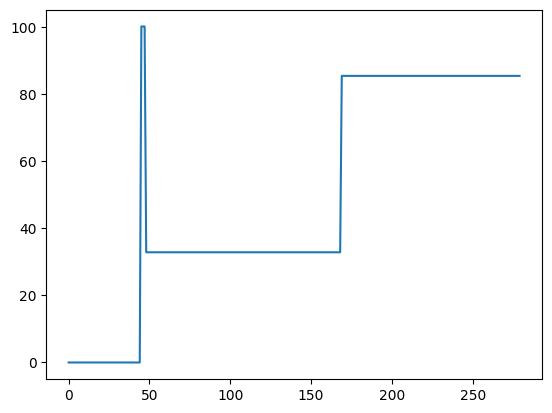

In [147]:
import matplotlib.pyplot as plt
plt.plot(equity)